# 8. プログラミング実践
## ファイル入出力

### **準備**

下図を参考に，Google Colabの「ファイル」を開きましょう．
  - 赤丸で示したフォルダ形状のアイコンをクリックします．

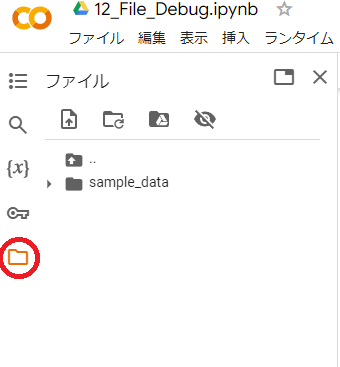

- しばらく待ち，ランタイムに接続すると，`sample_data`というファイルが見えるかと思います．
  - これはGoogle Colabによって自動で生成されるファイルです．
- 次に以下のコード（コマンド）を実行してください．
  - Google Colabでは，`!`をつけてシェルコマンドを実行できます．
    - LinuxやUnixを操作するためのコマンド
  - これはカレントディレクトリ（現在参照しているディレクトリ）の内容を表示するコマンドです．

In [ ]:
!ls

- `sample_data` が出力されるはずです

次に下記のプログラム実行を通じて`12_test.txt`をダウンロードしてください．



In [ ]:
!wget -O 12_test.txt "https://drive.google.com/uc?export=download&id=11BBAlzhXGesazBljGLWdBMHj0mFCB-r1"

ダウンロード後は以下のような表示になります．

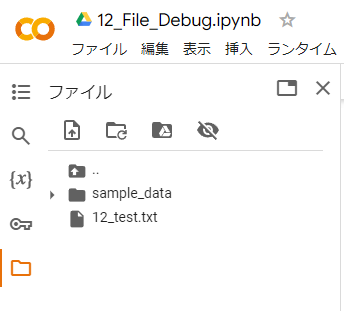

再度lsコマンドを実行すると，12_test.txtが追加されているはずです．

In [ ]:
!ls

- **Google Colabのファイルはランタイムの接続が解除されると消えてしまうので注意してください**
  - ここで操作したファイルが必要な時は，ランタイムが接続されている間にダウンロードする必要があります
    - マウスオーバーで出てくる「︙」メニューから「ダウンロード」できます
  - もしくは，自身のGoogle DriveをマウントしてGoogle Drive上のファイルを操作すればランタイムの接続が解除されてもファイルは消えません（興味がある方は各自で調べてください）

### **ファイル操作**

今回はテキストモードでのファイル操作を学習します．
- 上の**準備**で用意した`12_test.txt`を使用します．
  - ファイルを用意できていない場合は，**準備**の手順を行ってください．
- ファイルの内容を確認しておきましょう．
  - 12_test.txtをダブルクリックするとGoogle Colab上で開くことができます．
    ```
    aaa
    bbb
    abcdefg
    ```
    という内容になっています．
  - 1行目，2行目の行末には改行が入っています．
  - 文字列で表すとこのファイルは`aaa\nbbb\nabcdefg`という内容になります．
    - `\n`は改行を表す文字です．

#### **ファイルを開く・閉じる**

- Pythonでファイルを開くには**open関数**を，ファイルを閉じるには**closeメソッド**を使います
  - **openしたファイルは必ずcloseしましょう**
    - 書き込んだ内容が反映されない，などのバグの原因になります







- **open関数**
  - ファイルを開き，ファイルオブジェクトを返します．
    - 返ってきたファイルオブジェクトには`f`や`file`という変数を使うことが多いです．
  - 記法
    ```
    open(ファイル名[, モード[, エンコード[, エラー処理]]])
    ```
    - **ファイル名**は*パス*という表し方でファイルがある位置を指定します．
      - パスについてはOSの授業などで扱いますので詳しくは説明しませんが，下のコラムで簡単に説明していますので確認してください．
      - 今回はカレントディレクトリにあるファイルを操作する前提で説明しますので，`パス`には操作したいファイル名を指定するだけです．
        - カレントディレクトリは今現在開いているディレクトリです．
    - **モード**はファイルの読み書きの設定とテキストかバイナリかの設定を指定します．
      - *読み書きの設定*
        - *r*: ファイルを読み出し用に開きます．
          - 読み書きの設定を省略した場合のデフォルト値です．
          - 存在しないファイルを開こうとするとエラーになります．
        - *w*: 新規にファイルを作成し書き込みます．
          - 同名のファイルが存在する場合は上書きします．
        - *x*: 新規にファイルを作成し書き込みます．
          - 同名のファイルが存在する場合はエラーになります．
        - *a*: ファイルの末尾に追記します．
          - 同名のファイルが存在する場合はその末尾に追記，存在しない場合は新規作成します．
        - *+*: r，w，aと組み合わせて使うオプションで，読み出しと書き込みの両方が可能になります．
      - *テキスト/バイナリの設定*
        - *t*: ファイルの内容を文字列として開きます．
          - テキスト/バイナリの設定を省略した場合のデフォルト値です．
        - *b*: ファイルの内容をバイナリ（表現が難しいですが生のデータというイメージです）として読み書きします．
          - 例えば，10という数値をテキストモードで読み書きすると文字列としての「10」になりますが，バイナリモードでは整数型のデータとして読み書きします．
    - *エンコード*はテキストモードで開いた場合の文字コードを指定します．
      - `encoding='文字コード名'`のように指定します．
      - OSによってデフォルトの文字コードは異なります．
        - Windowsであれば`'shift-jis'`か`'cp932'`，MacOSやLinuxの多くは`'utf-8'`です．
      - 省略した場合はOSのデフォルトの文字コードに設定されます．
        - 省略できますが，**自分が作成したコードがどのような実行環境でも動作するように，省略せずに記述するべき項目です**．
        - テキストエディタなどで自分の使うファイルの文字コードを確認し，正しく設定してください．

- **closeメソッド**
  - closeはファイルオブジェクトのメソッドです．
  - 開いているファイルオブジェクトを閉じます．
  - 記法

    openしたファイルが`f`という変数に格納されているとします．
    ```
    f.close()
    ```

- 次のコードを実行してみましょう
  - 12_test.txtを開き，中身をすべて読み，出力し，閉じるという処理を行います
    - readメソッドについてはこの後に説明します

In [ ]:
f = open('12_test.txt', 'rt', encoding='utf-8')
s = f.read()
print(s)
f.close()

> **コラム：パスとは**
> - パスは，オペレーティングシステム（OS：Windows，MacOS，Linuxなど）のファイルシステムの中でファイルやディレクトリの位置を表すものです．
>   - ディレクトリはWindowsやMacOSではフォルダと呼ばれます．
> - Linuxではディレクトリの階層をたどるごとに`/`記号で区切ります．
>   - Windowsでは`\`記号で区切ります．
>   - 単に`/`とするとルートディレクトリと呼ばれるファイルシステムの階層の最上位を示します．
> - Windowsでフォルダやファイルを右クリックしプロパティを開いたときに「場所」に書かれている内容がパスになります．
>   - 正確には，「場所」はそのファイルもしくはフォルダがある位置なので，「場所」にその`\ファイル名`もしくは`\フォルダ名`をつなげるとファイルもしくはフォルダを表すパスになります．



#### **ファイルからデータを読み出す**

- 開いたファイルオブジェクトからデータを読み出すには**read**，**readline**，**readlines**メソッドを使います．
  - データの読み方がそれぞれ異なるので，作成したいプログラムに合わせてどれを使うかを考えましょう．
- **以降は，開いたファイルが `f`という変数に格納されている仮定で説明をします**．

##### **readメソッド**

- ファイルオブジェクトから**指定したサイズのデータを読み出し**ます．
- ファイルがテキストモードで開かれていた場合は文字列，バイナリモードで開かれていた場合はbytesオブジェクトを返します．
- 記法
  ```
  f.read([サイズ])
  ```
  - *サイズ*は，ファイルがテキストモードの場合は文字数，バイナリモードの場合はバイト数を指定します．
    - オプションを省略した場合はすべての内容を読み出します．
- 次のコードでサイズを指定しない場合の動作を確認しましょう．
  - 1つ前のコードと同じです．

In [ ]:
f = open('12_test.txt', 'rt', encoding='utf-8')
s = f.read()
print(s)
f.close()

- すべてのデータが読み出され，sは`aaa\nbbb\nabcdefg`という文字列が格納されます．
- 次に，サイズを指定する場合の動作を確認しましょう．

In [ ]:
f = open('12_test.txt', 'rt', encoding='utf-8')
s1 = f.read(5)
print(s1)
s2 = f.read(2)
print(s2)
s3 = f.read()
print(s3)
s4 = f.read()
if s4 == '':
    print('s4 is Empty')
f.close()

- 最初に，`f.read(5)`として，5文字を読み出しています．
  - **改行も1文字として数えるので注意してください**．
  - 5文字読み出すため，s1は`aaa\nb`となり，これを出力すると次のようになります．

  ```
  aaa
  b
  ```

  - `f.read(5)`によって5文字読み出したため，次に読み出す場合は残りの`bb\nabcdefg`というデータから読み出すことになります．
- 次の`f.read(2)`では`bb`の2文字が読み出されます．
  ```
  bb
  ```
- 次の`f.read()`で残りすべてのデータ，つまり`\nabcdefg`が読み出されます．
  - 改行から出力されるため下記のようになります．

  ```
  
  abcdefg
  ```
- すべてのデータを読み出したあとにさらにファイルを読み出すと空の文字列が返ります（テキストモードの場合）．
  - `if s4 == ''`がTrueとなり，Emptyが出力されています．

- **シーク位置**
  - ファイルへの読み書きは，シーク位置を対象に行われます．
    - シーク位置はテキストエディタでのカーソルのようなものです．
  - 読み，書きをすすめていくと，シーク位置がずれていきます．
    - 上のコードで確認したように，読み出すたびにシーク位置がずれ（その位置が記憶され）ます．
  - ファイルを開く際のモードの設定でシーク位置の初期値が変わります．
    - 書き込みの際に先頭から上書きするのか，末尾に追記するのかを使い分けます．

##### **readlineメソッド**
  - ファイルオブジェクトから**1行だけ読み出し**ます．
  - ファイルの終端を読み出すと空の文字列が返ります．
  - 記法
    ```
    f.readline([サイズ])
    ```
    - 1行だけ読み出す，つまり先頭から改行コードもしくはファイルの終端までの文字列を読み出すというメソッドです．
    - *サイズ*には読み出す最大の文字数を指定します．
      - 省略した場合は，改行コードもしくはファイルの終端まで読み出します．
      - 指定した文字数が改行コードもしくはファイルの終端までの文字列より小さい場合は，その文字数だけ読み出します．
      - 指定した文字数が改行コードもしくはファイルの終端までの文字列より大きい場合，改行コードもしくはファイルの終端まで読み出します．
  - 次のコードで動作を確認しましょう．

In [ ]:
f = open('12_test.txt', 'rt', encoding='utf-8')

# 1行目
s1 = f.readline()
print(f's1  :{s1}', end='')

# 2行目
s2_1 = f.readline(2)
print(f's2_1:{s2_1}')
s2_2 = f.readline(5)
print(f's2_2:{s2_2}', end='')

# 3行目
s3 = f.readline()
print(f's3  :{s3}')

# ファイルの終端
s4 = f.readline()
if s4 == '':
    print('EOF')

f.close()

- 最初の`f.readline()`はサイズ指定をしていないため1行読み出します．
  - s1は`aaa\n`となります．
    - 行末の改行コードまで読み出していることを注意してください．
  - 行末の改行コードとprintの自動改行が重複しないように`end=''`を使っています．
- 次の`f.readline(2)`で，残りのデータ`bbb\nabcdefg`から2文字目までを読み出します．
  - s2_1は`bb`となります．
  - s2_1のprintでは文字列に改行が入っていないため`end=''`オプションはなしにしています．
- 次の`f.readline(5)`で，残りのデータ`b\nabcdefg`から5文字読み出そうとしますが，2文字目に改行コードがあるため`b\n`までしか読み出しません．
  - s2_2は`b\n`となります．
- 3行目を読み出す`f.readline()`ではファイルの残りのデータがすべて読み出されます
  - s3は`abcdefg`となります．
  - 3行目には改行コードが入っていません．
    - ここのprintは改行ありで出力しています．
- 最後の`f.readline()`では，ファイルの終端を読み出すと空の文字列が返ることが確認できます．

##### **readlinesメソッド**

- ファイルオブジェクトから**すべてのデータを，行ごと分割したリストとして読み出し**ます．
- 記法
  ```
  f.readlines([サイズ])
  ```
  - *サイズ*では読み出す文字数を指定します．
    - 省略した場合はファイルのすべてのデータを読み出します．
    - サイズを指定した時の使い方はやや複雑で，指定した文字数までが含まれる行を読み出します．
- 次のコードでサイズを指定しない場合の動作を確認しましょう．


In [ ]:
f = open('12_test.txt', 'rt', encoding='utf-8')
list = f.readlines()
print(list)
f.close()

- readlines()で読み出すと，**各行が要素となるリスト**が返ります．
  - ファイルの1行目が0番目の要素，2行目が1番目の要素，，，です．
  - 12_test.txtの各行がリストの要素となって読み出されることが確認できます．
  - ここでも行末の改行コードまで読み出していることに注意してください．
- 次にサイズを指定した場合の動作を確認しましょう．

In [ ]:
f = open('12_test.txt', 'rt', encoding='utf-8')
list1 = f.readlines(2)
print(f'list1:{list1}')
list2 = f.readlines(7)
print(f'list2:{list2}')
list3 = f.readlines()
print(f'list3:{list3}')
f.close()

- 最初の`f.readlines(2)`では，文字数2を指定しています．
  - readlinesで読み出されるデータは，**行単位**なので，2文字目の`a`を含む1行，つまり`aaa\n`まで読み出され．
  - `['aaa\n']`というリストが返ってきます．
- 次の`f.readlines(7)`では，文字数7を指定しています．
  - `bbb\n`は4文字なので，ここまででリストの1つの要素となります．
  - 5文字目の`c`を含む行，つまり`abcdefg`が次の要素となります．
  - したがって，`['bbb\n', 'abcdefg']`というリストが返ってきます．
- 最後の`f.readlines()`ではファイルの終端を読み出すと**空のリスト**が返ってくることが確認できます．

##### **ファイルからfor文を使って1行ずつ読み出す**

- テキストファイルをプログラムで扱う場合，1行ずつ読み出しながら何か処理をするということが多くあります．
- これまでに説明したファイルオブジェクトのメソッドを使っても1行ずつ読み出して何か処理をするプログラムを作ることができます．
- 実は，ファイルオブジェクト自体が*シーケンス*になっており，for文で1行ずつ読み出すことができます．
- 次のコードで確認しましょう．

In [ ]:
f = open('12_test.txt', 'rt', encoding='utf-8')
for s in f:
    print(s, end='')
f.close()

- ファイルが1行ずつ読み出されていることが確認できます．
- このコードは，例えば次のコードと同じ動きになります．
  ```
  f = open('12_test.txt', 'rt', encoding='utf-8')
  for s in f.readlines():
      print(s, end='')
  f.close()
  ```
  - readlines()を使うとコンピュータ上のメモリをより多く使ってしまいます．
    - サイズの大きなファイルを扱うと，すべてのデータが読み出せないなどの不具合が起きる可能性があります．

- 次のコードも同様の動きになります．
  ```
  f = open('12_test.txt', 'rt', encoding='utf-8')
  while True:
      s = f.readline()
      if s == '':
          break
      print(s, end='')
  f.close()
  ```
- 大きなファイルを扱う時や1行ずつ処理する場合はfor文を使ってファイルオブジェクトからそのまま読み出す方法がよいでしょう．

#### **ファイルへの書き込み**

- ファイルオブジェクトのメソッド，**write**や**writelines**を使うとファイルに文字列を書き込むことができます．
- ファイルに書き込むためにはopen関数でファイルを開く際に書き込み可能な`モード`で開く必要があります．
  - 書き込むモードは**w**，**a**，**x**の3種類です（上のopen関数のセクションで再度確認しましょう）．
- writeメソッドやwritelinesメソッドはprint関数のように自動で改行が入らないので，適切に改行コードを含めて書き込む必要があります．
- 以降は，開いたファイルが `f`という変数に格納されている仮定で説明をします．

##### **writeメソッド**

文字列をファイルに書き込みます．
- 記法
  ```
  f.write(文字列)
  ```
  
  - *文字列*で指定した文字列がファイルのシーク位置から書き込まれます．
    - 文字列が格納された変数を指定することも，`'`もしくは`"`でくくり直接文字列を指定することもできます．
    - 文字列である必要があるので，数値は文字列に変換する必要があります．
      - print関数では変数の値をそのまま文字列として出力することができましたが，writeではできません．
- 次のコードで動作を確認しましょう．

In [ ]:
f = open('new.txt', 'w', encoding='utf-8')
a = 10
f.write(f'hogehoge {a}\n')

f.write(str(a))
print(a)

f.close()

- new.txtというファイルを作成して文字列を書き込みます．
  - 作成されたnew.txtを開いて確認しましょう．
  - 「ファイル」にnew.txtがない場合は右クリックして「更新」をしてみてください．
  - 下記が書き込まれているはずです．
  ```
  hogehoge 10
  10
  ```
- このコードはファイルをモード `w` で開いています．
  - すでにnew.txtが存在していても新しいファイルで上書きをするモードです．
    - 上のコードを何度か実行しても，文字列が追記されないので新しいファイルが上書きされていることが確認できます．
- aという整数が格納された変数を使い，文字列をファイルに書き込みます．
- 最初のwriteでは，f文字列で`hogehoge 10\n`という文字列を作り書き込みます．
- 次のwriteでは，数値を文字列に変換して書き込みます．
  - printでは変数aの値はそのまま出力することができますが，writeでは`str(a)`のように文字列に変換する必要があります．

##### **writelinesメソッド**
文字列のリストをファイルに書き込みます．
- 記法
  ```
  f.writelines(文字列のリスト)
  ```
  - 指定するリストの要素はすべて文字列である必要があります．
- 次のコードで動作を確認しましょう．


In [ ]:
f = open('new.txt', 'w', encoding='utf-8')

f.writelines(['hoge\n', 'foo'])

f.close()

- 文字列のリストを作り，new.txtに書き込みます．
  - new.txtを開いて確認しましょう．
    ```
    hoge
    foo
    ```
    となっているはずです
  


#### **安全なファイルのOpen**
* openしたファイルは必ずcloseする必要があります．
* ただ，closeし忘れることがよくあります．
* `with`を使ってopenすると，withのブロックが終了すると自動でファイルをcloseできます．
* 次のコードは上のコードのwithを使う場合です．

In [ ]:
with open('new.txt', 'w', encoding='utf-8') as f:
    f.writelines(['hoge\n', 'foo'])

* 1行目が`with`を使ったファイルを開くコードです．
  * `as f`とすることで開いたファイルオブジェクトに`f`という名前をつけます．
* 2行目の`f.writelines`がwithのブロック内にあり，fに対して書き込み処理が行われます．
* withブロックを抜けると自動でファイルはcloseされます．
* 次のコードで，3行目では`f`が参照できずにエラーになるのを確認しましょう．
  * ノートブック内で変数`f`を使い回しているので，エラーにならないかもしれません．
  * その場合はランタイムの再起動を行ってください．

In [ ]:
with open('new.txt', 'w', encoding='utf-8') as f:
    f.writelines(['hoge\n', 'foo'])
f.writelines(['hoge\n', 'foo'])

## NumPy

ここでは，数値計算ライブラリ **NumPy** の基本を学びます．

### 学習目標
- NumPyとは何かを理解する．
- ndarray（多次元配列）の作成方法を理解する．
- 要素アクセス，スライス，演算を扱えるようになる．
- 配列を用いた統計量計算や乱数生成を理解する．
- データサイエンス基礎につながる利用法を知る．

### NumPyとは
- Pythonの数値計算を効率的に行うためのライブラリ
- 多次元配列（`ndarray`）を中心に設計
- 線形代数，統計処理，乱数生成などの関数を多数提供
- Pandas，scikit-learn，TensorFlowなどの基盤となっている

NumPyは，通常次のようにimportすることで利用可能になります．  

In [ ]:
# NumPyの読み込み
import numpy as np

ここでnpはnumpyを参照する際の別名です．今後はnumpyを参照する際は別名npを使います．

### 配列の作成
NumPyでは，`np.array`を使ってリストから配列を作成できます．
また，便利な初期化関数も用意されています．

In [ ]:
# np.array(リスト, dtype=データ型)
# リストを「NumPyの配列」に変える
#   リスト : [ ] を用いて作ったPythonのリスト
#   dtype  : 数値の型（int=整数型, float=浮動小数点型）を指定
narr = np.array([1, 2, 3, 4, 5], dtype=int)
print("narr =", narr)

# np.zeros(shape, dtype=float)
# 「すべての要素が0」の配列を作る
#   shape : 配列の形（行数や列数など）をタプルで指定
#   dtype : 数値の型（省略するとfloat）
nzero = np.zeros((2,3))
print("nzero =\n", nzero)

# np.ones(shape, dtype=float)
# 「全ての要素が1」の配列を作る
#   shape : 配列の形（行数や列数など）をタプルで指定
#   dtype : 数値の型（省略するとfloat）
none = np.ones((3,2))
print("none =\n", none)

# np.arange(start=0, stop, step=1)
# 「等間隔の数列」の配列を作る
#   start : 始まりの数値（省略すると0）
#   stop  : 終わりの数値（ただしstopは含まれない）
#   step  : 増える間隔（省略すると1）
nseq = np.arange(1,6)
print("nseq =\n", nseq)

# np.linspace(start, stop, num=50)
# 「区間を等分した数列」の配列を作る
#   start : 始まりの数値
#   stop  : 終わりの数値（含まれる）
#   num   : 分割する数（いくつに区切るか，省略すると50）
nlin = np.linspace(0,1,5)
print("nlin =\n", nlin)


### 配列へのアクセス
NumPyの配列は**インデックス**（添字）を指定して要素にアクセスします．  
また，**スライス**を使えば，部分配列を取り出すことも可能です．

In [ ]:
# 要素アクセス（インデックス指定）
# [ ] 内にインデックスを入れる
# 1次元配列なら1つ、2次元以上ならタプルで指定する

narr1 = np.ones(5)
print("narr1 =", narr1)

narr1[1] = 2   # インデックス1の要素を変更
print("narr1 =", narr1)

narr2 = np.ones((3,2))
print("narr2 =\n", narr2)

narr2[1,0] = 5   # 2行目1列目の要素を変更
print("narr2 =\n", narr2)

# スライス（部分配列の取り出し）
# [ start : stop : step ] の形式で指定
#   start : 開始位置（省略すると0）
#   stop  : 終了位置（stopは含まれない）
#   step  : 増分（省略すると1）

narr3 = np.arange(10)   # 0〜9の配列
print("narr3 =", narr3)

print("narr3[1:] =", narr3[1:]) # インデックス1以降
print("narr3[:-1] =", narr3[:-1]) # 最後の要素より前
print("narr3[::2] =", narr3[::2]) # 2つ飛ばし

narr4 = np.arange(6).reshape(3,2) # 1次元配列を2次元配列(3行2列)に再構成
print("narr4 =\n", narr4)

print("narr4[0, :] =", narr4[0, :]) # 1行目を取得
print("narr4[:, 0] =", narr4[:, 0]) # 1列目を取得


### **shape属性**
NumPyの配列の**形**（各次元の要素数）は**shape**で調べられます．

In [ ]:
# 3次元配列を作成（3×2×4）
narr5 = np.ones((3,2,4))
print("narr5 =\n", narr5)

# 配列の形をタプルで取得
print("narr5.shape =", narr5.shape)

# 各次元の要素数を個別に確認
print("narr5.shape[0] =", narr5.shape[0])  # 1次元目（行数）
print("narr5.shape[1] =", narr5.shape[1])  # 2次元目（列数）
print("narr5.shape[2] =", narr5.shape[2])  # 3次元目（深さ）


### **配列の演算**
NumPyの配列では，**要素**間に四則演算（+ - * /）が適用できます．  
また，**スカラ**（簡単に言えば，単一の実数）との演算も可能です．

In [ ]:
# 1～5の配列を作成
a = np.arange(1,6)
print("a =", a)

# 6～10の配列を作成
b = np.arange(6,11)
print("b =", b)

# 同じ位置の要素同士を演算
print("a + b =", a + b)
print("a - b =", a - b)
print("a * b =", a * b)
print("a / b =", a / b)

# スカラとの演算（各要素に同じ処理が行われる）
print("a + 10 =", a + 10)
print("a * 0.5 =", a * 0.5)


### ブロードキャスト

NumPyでは，形が違う配列同士でもあるルールに従って自動的に形を揃えて演算できる場合があります．
これを**ブロードキャスト**（broadcasting） と呼びます．

たとえば，配列とスカラーの演算を「スカラ値がすべての要素と計算される」と考えるとイメージしやすいと思います．  
同様に1次元配列と2次元配列でも「小さい方の配列を自動的に拡張」して計算ができます．

ブロードキャストを理解すると，for文を書かずに複雑な処理が簡単に表現できる可能性があります．

**ブロードキャストのルール**

配列の形（shape）の右端から比べたとき，
1. **次元数が少ない方は，左側に1を補って揃える．**  
1. 対応する次元が**同じ数**または**どちらかが1**ならばOK
1. **1**である次元は「もう一方の数に合わせて拡張されたように扱われる」  

**例**：(3,1) と (4,) の演算
1. (4,) は次元数が足りていないので、左に1を補って(1,4)と考える．
2. (3,1) と (1,4) を比較  
   - 右端: 1 と 4 → 片方が1なのでOK  
   - 左端: 3 と 1 → 片方が1なのでOK  
3. それぞれ (3,4) に拡張されたように扱われ計算できる．
   - 右端が1の方はもう一方の数（4）に合わせるように拡張されるように扱われる．
   - 左端が1の方はもう一方の数（3）に合わせるように拡張されるように扱われる．

In [ ]:
a = np.arange(1, 6)
print("a =", a)

# スカラとの演算（スカラが配列の大きさに拡張されるイメージ）
print("a + 10 =", a + 10)   # 各要素に10を足す
print("a * 2  =", a * 2)    # 各要素を2倍

#このとき a = [1 2 3 4 5]
#スカラ10をaに合わせて拡張すると，
#10 → [10] → [10 10 10 10 10]になる．

以下のプログラムでは，`narr1`を自動的に (1,3) に拡張し，さらに行方向にコピーして (3,3) として演算します．

In [ ]:
narr1 = np.arange(3)        # [0 1 2]
print("narr1 =", narr1)

narr2 = np.ones((3,3))      # 3x3の3行3列
print("narr2 =\n", narr2)

# 1次元配列 narr1 が (1,3) → (3,3) に拡張されて計算される
print("narr2 + narr1 =\n", narr2 + narr1)

#このとき narr1 = [0 1 2]
#narr2 =
#[[1. 1. 1.]
# [1. 1. 1.]
# [1. 1. 1.]]
#
#narr1の形は(3,)，narr2の形は(3,3)なので，次元数が足りていない
#narr1の形を(1,3)とみなす．つまり，[[0 1 2]]とみなす．
#narr1とnarr2の形について，右側は3と3で同数でOK，左側は1と3で片方1なのでOK．
#narr1の(1,3)を(3,3)に拡張したように扱う．
#そのときのnarr1（のイメージ）は以下になる．
#[[0 1 2]
# [0 1 2]
# [0 1 2]]
#そして，「この（イメージの）narr1」と「narr2」を加算すると以下になる．
#[[1. 2. 3.]
# [1. 2. 3.]
# [1. 2. 3.]]
#
#注意：実際にメモリ上で[0 1 2]が2行目と3行目にコピーされる訳ではありません．
#あくまで「コピーされたように扱われる」だけです．
#そのため，このように拡張されたように見える配列は変数として保存されません．
#以下のようにnarr1をprintしても，当初の[0 1 2]と表示されます．
print("narr1 =", narr1)


以下のプログラムでは，`row`の形が (3,) から (1,3) にみなされ，さらに`col`と`row`がともに (3,3) に揃えられて演算される．

In [ ]:
col = np.array([[1], [2], [3]])   # 3x1 の列ベクトル
print("col =\n", col)

row = np.array([10, 20, 30, 40])      # 1x4 の行ベクトル
print("row =", row)

# col(3,1)はrowを踏まえて(3,4)にブロードキャスト
# row(1,4)はcolを踏まえて(3,4)にブロードキャスト
print("col + row =\n", col + row)


以下のプログラムでは，ブロードキャストが**できない**ために，エラーになります．

In [ ]:
x = np.ones((2,3))   # 2x3
y = np.ones((4,3))   # 4x3

# xとyの形で2と4の部分がルールを満たさないのでブロードキャストできない
print(x + y)   # エラー

### **次元変換（reshape, flatten）**

NumPyでは，配列の**形（行数や列数）**を変えることができます．
- **reshape** : 配列を指定した形に並べ替える
- **flatten** : 多次元配列を1次元に変える

ただし，形を変える場合も**要素数の合計**が変わる方法は採れません．

In [ ]:
# 0～5の配列（1次元）
narr = np.arange(6)
print("narr =", narr)

# 2行3列に変換
narr_reshaped = np.reshape(narr, (2,3)) # numpyのreshapeにより2行3列に変換
print("np.reshape(narr, (2,3)) =\n", narr_reshaped)

# reshape はメソッドでも同じ
narr2 = np.arange(12)
print("narr2 =", narr2)

narr2_reshaped = narr2.reshape(3,4)  # narr2のreshapseにより3行4列に変換
print("narr2.reshape(3,4) =\n", narr2_reshaped)

# flatten で1次元に戻す
narr3 = np.arange(6).reshape(2,3)
print("narr3 =\n", narr3)

narr3_flat = narr3.flatten()
print("narr3.flatten() =", narr3_flat)


### **集約関数（sum, mean, max, min, std）**

データを分析するとき，配列の合計や平均，最大値，最小値などの統計量を一度に求められると便利です．  
NumPyでは次の関数をよく使います．
- **sum()** : 合計
- **mean()** : 平均
- **max()** : 最大値
- **min()** : 最小値
- **std()** : 標準偏差（データのばらつき）

In [ ]:
narr = np.array([1, 2, 3, 4, 5])
print("narr =", narr)

print("narr.sum() =", narr.sum())     # 合計
print("narr.mean() =", narr.mean())   # 平均
print("narr.max() =", narr.max())     # 最大値
print("narr.min() =", narr.min())     # 最小値
print("narr.std() =", narr.std())     # 標準偏差


### **axis**

多次元配列に対して集約関数を使うとき，どの方向に処理をするかを指定できます．  
この方向を決めるのが**axis**です．
- **axis=0** : 行方向（行を跨ぐよう縦方向）に数値を集約 → 列ごとに結果が得られる
- **axis=1** : 列方向（列を跨ぐよう横方向）に数値を集約 → 行ごとに結果が得られる

In [ ]:
narr = np.array([[1, 2, 3],
                 [4, 5, 6]])
print("narr =\n", narr)

# 配列全体の合計
print("narr.sum() =", narr.sum())

# 行方向に合計（列ごとに合計）
print("narr.sum(axis=0) =", narr.sum(axis=0))

# 列方向に合計（行ごとに合計）
print("narr.sum(axis=1) =", narr.sum(axis=1))


## NumPyによるデータサイエンスの導入



### **疑似乱数**

NumPyでは，`np.random`モジュールを使うと**擬似乱数**（見かけ上ランダムな数）を生成できます．  
擬似乱数は実験データのシミュレーションなどによく使います．

**擬似乱数の特徴**
- 同じ**種**（seed）を与えると，毎回同じ乱数列が生成される
- 実験で用いた乱数列を**再現**できるので便利

#### 擬似乱数の生成


In [ ]:
# np.random.seed(seed)
# 乱数の「種」を固定する（同じseedなら同じ乱数列が再現される）
#   seed : 整数（任意の好きな数）
np.random.seed(123)

x1 = np.random.rand(3)
print("x1 =", x1)

# 同じseedをもう一度設定してから生成すると、まったく同じ並びになる
np.random.seed(123)
x2 = np.random.rand(3)
print("x2 =", x2)


#### 擬似乱数の分布（代表的なもの）

- **一様分布**：0以上1未満の小数を等確率  
- **正規分布**：平均0・標準偏差1を基準に`μ + σ * randn(...)` で一般化  

In [ ]:
# np.random.rand(d0, d1, ...)
# 「一様分布 U[0,1)」に従う擬似乱数
#   d0, d1, ... : 生成する配列の形（省略すると単値）
u = np.random.rand(5)
print("u =", u)

# np.random.randn(d0, d1, ...)
# 「標準正規分布 N(0,1)」に従う擬似乱数
z = np.random.randn(5)
print("z =", z)

# 平均mu, 標準偏差sigma の正規分布 N(mu, sigma^2) に従う擬似乱数
mu, sigma = 10, 2
z_general = mu + sigma * np.random.randn(5)
print("z_general =", z_general)

# np.random.randint(low, high=None, size=None)
# 整数の一様分布（[low, high) の範囲、highは含まない）
#   low  : 最小値（含む）
#   high : 最大値（含まない）※省略すると 0〜low の範囲になる
#   size : 生成する個数（配列の形）
ri = np.random.randint(0, 10, size=5)
print("ri =", ri)


### 擬似乱数による統計量算出
既に一部を紹介しましたが，データをまとめるときによく使う指標があります．

- **mean()** : 平均（データの中心）
- **std()** : 標準偏差（散らばり具合）
- **min(), max()** : 最小値・最大値
- **median()** : 中央値（データを小さい順に並べたときの真ん中）
- **percentile(p)** : 下から数えて`p%`の位置にある値（四分位点などを求めることに利用）

特に **四分位点（quartile）** はデータを 4 つに分ける位置を示します．
- 第1四分位点 (Q1) = 25%点 = `np.percentile(data, 25)`
- 第2四分位点 (Q2) = 50%点 = 中央値 = `np.median(data)`
- 第3四分位点 (Q3) = 75%点 = `np.percentile(data, 75)`

これにより「データの広がり」をより直感的に把握できます．

In [ ]:
# 標準正規分布から1000個のサンプルを作成
data = np.random.randn(1000)

print("mean   =", data.mean())        # 平均
print("std    =", data.std())         # 標準偏差
print("min    =", data.min())         # 最小
print("max    =", data.max())         # 最大

# 中央値と四分位点
print("median =", np.median(data))               # 中央値
print("Q1 (25%) =", np.percentile(data, 25))     # 第1四分位点
print("Q2 (50%) =", np.percentile(data, 50))     # 第2四分位点（中央値）
print("Q3 (75%) =", np.percentile(data, 75))     # 第3四分位点


### データの可視化（基礎）

データの分析では，数値を**グラフで可視化**すると理解しやすくなります．  
Pythonでは**matplotlib**というライブラリがよく使われます．

データの可視化について，基本的な流れは次の通りです．
1. `import matplotlib.pyplot as plt` で読み込む，
1. `plt.plot(...)` や `plt.hist(...)` などで描画する．
1. `plt.show()` で表示する．

今回は乱数の分布を「ヒストグラム」で表示してみます．

In [ ]:
# matplotlibを使う準備
import matplotlib.pyplot as plt

#### ヒストグラムでデータの分布を可視化

**ヒストグラム**とは，データを区間（ビン）に分けて**どれくらい頻出したか**を棒グラフで表したものです．  

- `bins` : 棒の本数（区切る数）  
- `range` : データの範囲  
- `density=True` : 面積が1になるように正規化（サンプル数が違っても比較しやすい）  

例として「標準正規分布 N(0,1)」から1000個の擬似乱数を作って描画します．


In [ ]:
# 標準正規分布から1000個のサンプルを生成
data = np.random.randn(1000)

plt.hist(data, bins=30, density=True, alpha=0.7)
plt.xlabel("value")               # x軸ラベル（英語）
plt.ylabel("density")             # y軸ラベル（英語）
plt.title("Histogram of N(0,1) random samples (N=1000)")  # タイトル（英語）
plt.grid()
plt.show()


#### サンプル数による分布の違い

標準正規分布 N(0,1)では，サンプル数（N）が少ないと分布は歪になりに，多くすると理論的な分布（釣鐘型）に近づいていきます．

In [ ]:
x1 = np.random.randn(100)    # N=100
x2 = np.random.randn(1000)   # N=1000
x3 = np.random.randn(10000)  # N=10000

plt.hist(x1, bins=30, density=True, alpha=0.5, label="N=100")
plt.hist(x2, bins=30, density=True, alpha=0.5, label="N=1000")
plt.hist(x3, bins=30, density=True, alpha=0.5, label="N=10000")
plt.xlabel("value")
plt.ylabel("density")
plt.title("Effect of sample size on random distribution")
plt.legend()
plt.grid()
plt.show()


#### 散布図と相関

2つの変数の関係の強さを表す指標を**相関** (correlation)と呼びます．  
相関を数値で表したものが**相関係数** (correlation coefficient)です．

相関係数の範囲は **-1 ～ +1**  
- **+1** : 完全な正の相関（きれいな右上がり直線）
- **0**  : 無相関（ばらばらに散らばる）
- **-1** : 完全な負の相関（きれいな右下がり直線）

相関係数 r の目安
- |r| ≧ 0.7 ならば 強い相関
- 0.4 ≦ |r| < 0.7 ならば 中程度の相関
- |r| < 0.4 ならば 弱い相関

2つの変数の関係を直感的に把握するときは**散布図**(scatter plot)を使います．


In [ ]:
# 強い正の相関を持つデータを作成
x = np.random.randn(1000)
y = 2*x + np.random.randn(1000)*0.5  # xに比例 + ノイズ

plt.scatter(x, y, alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot (positive correlation)")
plt.grid()
plt.show()

# 相関係数を計算
# np.corrcoef(x, y) は「相関行列」を返す
#   相関行列とは「各変数どうしの相関係数を並べた2次元配列」
#   例: 2変数x,yなら [[1, r], [r, 1]] という形になる
#   　　言い換えると[[xとxの相関係数, xとyの相関係数]，[yとyの相関係数, yとxの相関係数]]という形になる
#   　　そのため，[0,1] または [1,0] が xとyの相関係数 の場所を示すインデックスとなる
r = np.corrcoef(x, y)[0,1]
print("相関係数 r =", r)

この例では，点が右上がりの帯に沿って並んでいます．  
相関係数rは0.9前後となり，「強い正の相関」があることがわかります．


In [ ]:
# データ数を指定
N = 500

# 共通の説明変数xを標準正規分布 N(0,1) から生成
# np.random.randn(N) は平均0, 分散1の正規分布に従う乱数をN個作る
x = np.random.randn(N)

# 正の相関を持つデータ
#   xに比例（1.5倍）させて，さらに小さなノイズ（標準偏差0.3）を加える
#   → xが大きいとyも大きくなる「右上がり」の散布図になる
y_pos = 1.5*x + np.random.randn(N)*0.3

# 負の相関を持つデータ
#   xにマイナスをかけることで，xに反比例させるようにする
#   → xが大きいとyは小さくなる「右下がり」の散布図になる
y_neg = -1.5*x + np.random.randn(N)*0.3

# 相関がないデータ
#   xとは無関係に新しく乱数を生成
#   → xとyが独立なので散布図はバラバラに点が広がる
y_none = np.random.randn(N)

# 相関係数を計算
r_pos = np.corrcoef(x, y_pos)[0,1]
r_neg = np.corrcoef(x, y_neg)[0,1]
r_none = np.corrcoef(x, y_none)[0,1]

# グラフの準備
# plt.subplots(行数, 列数, figsize=(横インチ, 縦インチ))
fig, axs = plt.subplots(1,3, figsize=(15,4))

# 散布図を描画
# scatter(x, y, alpha) : xとyの点を散布図に描く
#   alpha=透明度（0~1で指定）
axs[0].scatter(x, y_pos, alpha=0.5)
axs[0].set_title(f"Positive corr (r={r_pos:.2f})")

axs[1].scatter(x, y_neg, alpha=0.5)
axs[1].set_title(f"Negative corr (r={r_neg:.2f})")

axs[2].scatter(x, y_none, alpha=0.5)
axs[2].set_title(f"No corr (r={r_none:.2f})")

plt.show()


この例では：

- **Positive corr** → 相関係数 r ≈ +0.9  
  → 強い正の相関（右上がり）

- **Negative corr** → 相関係数 r ≈ -0.9  
  → 強い負の相関（右下がり）

- **No corr** → 相関係数 r ≈ 0  
  → 相関なし（ばらばらに散らばる）

このように散布図で「形」を確認しつつ，相関係数の数値で「強さ」を判断できます．


## Pandas

- Pythonで 表形式のデータ（表＝DataFrame） を扱うためのライブラリ
- ExcelやCSVのような「行と列からなるデータ」を処理できる
- データ分析の基盤として有用

### 学習目標
- Pandasでデータを **読み込む**  
- データを **行・列で抽出する**  
- データを **集計・要約** する  
- データを **簡単に可視化** する  

In [ ]:
# Pandasを利用する準備
import pandas as pd

### データ構造
Pandasには主に2つのデータ構造があります．  

- **Series** : 1次元データ（列ベクトルのイメージ）  
- **DataFrame** : 2次元データ（表のイメージ）  


In [ ]:
# Seriesの例
s = pd.Series([10, 20, 30, 40])
print("Series:")
print(s)


In [ ]:
# DataFrameの例
data = {
    "Name": ["Alice", "Bob", "Charlie"],
    "Age": [24, 27, 22],
    "Score": [85, 90, 88]
}
df = pd.DataFrame(data)
print("DataFrame:")
print(df)


### CSVファイルの読み込み
実際のデータ分析では，CSVファイルからデータを読み込むのが基本です．  
ここではサンプルとして「アヤメのデータセット」を使います．  
このデータセットは，後述するライブラリseabornが提供しており，  
https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv  
から取得できます．ライブラリから直接読み込むことができますが，  
CSVファイル取得のアクセス負荷を考慮し，内容を転記したファイルを  
Googleドライブ経由で取得することにします．

In [ ]:
!wget -O iris.csv "https://drive.google.com/uc?export=download&id=1dxdLfIO3JUHj8JhbfXbZXWBen33dK1A3"

In [ ]:
# CSVファイルを読み込む
# 後述するライブラリseabornが提供するアヤメのデータセットを利用する
# ライブラリからロードできるが，ここでは敢えてCSV形式ファイルから読み込む
df = pd.read_csv("iris.csv")
print(df.head())   # 先頭5行を表示

### DataFrame基本操作

ここでは，Pandasの**DataFrame**を使った基本操作を学びます．  
小さな表データを用意して，データ型の変換や行・列の抽出，並べ替えなどを体験します．

In [ ]:
import pandas as pd

# サンプルの DataFrame を作成
df = pd.DataFrame({
    "A": [1.0, 2.0, 3.0],
    "B": [10, 20, 30],
    "C": ["2021-01-01", "2021-02-01", "2021-03-01"]  # 日付文字列
}, index=["row1", "row2", "row3"]) # 行ラベルを指定

print("df =\n", df)
# 各列のデータ型を確認
print("df.dtypes =\n", df.dtypes)

#### データ型の確認と変換

In [ ]:
# A列を整数に変換（例：float→intにする場合）
df["A"] = df["A"].astype(int)
print("A列を整数型に変換 =\n", df)

# C列を日付に変換
df["C"] = pd.to_datetime(df["C"])
print("C列を日付型に変換 =\n", df)
print("データ型 =\n", df.dtypes)



#### 列の追加・削除・名前変更


In [ ]:
# 計算して新しい列を追加
df["new_col"] = df["A"] + df["B"]
print("df（new_col追加） =\n", df)

# 列を削除
# axis=1で列削除，axis=0にすると行削除
df_dropped = df.drop("new_col", axis=1)
print("df_dropped =\n", df_dropped)

# 列の名前を変更
df_renamed = df.rename(columns={"A": "col_A"})
print("df_renamed =\n", df_renamed)


#### 並べ替え


In [ ]:
# 列Bで昇順(ascending=True)に並べ替え
print("df.sort_values('B', ascending=True) =\n", df.sort_values("B", ascending=True))

# 列Bで降順(ascending=False)に並べ替え
print("df.sort_values('B', ascending=False) =\n", df.sort_values("B", ascending=False))

# インデックスで並べ替え
print("df.sort_index() =\n", df.sort_index())


#### 行の抽出

In [ ]:
# 単一条件で抽出：B > 20
print("df[df['B'] > 20] =\n", df[df["B"] > 20])

# 複数条件で抽出：(A < 3) & (B > 10)
print("df[(df['A'] < 3) & (df['B'] > 10] =\n", df[(df["A"] < 3) & (df["B"] > 10)])


#### 行・列の選択

- **`loc`** : 行や列を「ラベル（名前）」で指定  
- **`iloc`** : 行や列を「番号（インデックス）」で指定  

基本形：  
- `df.loc[行ラベル, 列ラベル]`  
- `df.iloc[行番号, 列番号]`  

In [ ]:
# 1列を選択
print("df['C'] =\n", df["C"])

# 複数列を選択
print("df[['A','C']] =\n", df[["A", "C"]])

# 行を選択（先頭3行）
print("df.head(3) =\n", df.head(3))

# loc の例（ラベル指定）
print("df.loc['row2'] =\n", df.loc["row2"])
print("df.loc[['row1','row3'], ['A','C']] =\n", df.loc[["row1","row3"], ["A","C"]])
print("df.loc[df['A'] > 20, ['A','B']] =\n", df.loc[df["A"] > 20, ["A","B"]])

# iloc の例（番号指定）
print("df.iloc[1] =\n", df.iloc[1])                          # 2行目
print("df.iloc[[0,2], [0,2]] =\n", df.iloc[[0,2], [0,2]])    # 1・3行目 × A,C列
print("df.iloc[:3, :2] =\n", df.iloc[:3, :2])                # 先頭3行 × A,B列


### 集計・統計
Pandasには便利な集計関数が多数用意されています．  


In [ ]:
df = pd.read_csv("iris.csv")  # データセットをアヤメのものに戻す

In [ ]:
print(df.describe())   # 基本統計量
print(df["sepal_length"].mean())  # 平均
print(df["sepal_length"].std())   # 標準偏差
print(df["species"].value_counts()) # カテゴリごとの数

### 可視化
Pandasはmatplotlibと連携して簡単にグラフを描けます．  


In [ ]:
import matplotlib.pyplot as plt

# ヒストグラム
df["sepal_length"].hist()
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()


#### Boxplot（箱ひげ図）

箱ひげ図は**データのばらつき**や**外れ値**を一目で確認できる便利なグラフです．  
以下の要素で構成されています．
- **箱（四角形）**
  - 箱の下端：第1四分位点（Q1）＝ 下位25%の値
  - 箱の中央線：中央値（Q2）＝ データの真ん中
  - 箱の上端：第3四分位点（Q3）＝ 上位25%の値

- **ひげ（線）**
  - データの「外れ値でない範囲」を示す
  - 範囲の定義は**Q1 − 1.5×IQR**から**Q3 + 1.5×IQR**
    - Q1：第1四分位点（25%点）
    - Q3：第3四分位点（75%点）
    - IQR = Q3 − Q1 （四分位範囲）
  - この範囲の中で一番小さい値と一番大きい値にひげが伸びる


- **外れ値（点）**
  - ひげの外にあるデータ点
  - 他と比べて極端に大きい/小さい値を示す

### 読み方の例
- 箱が縦に長い → データのばらつきが大きい  
- 箱の位置が上にある → 値が全体的に大きい  
- 中央線が箱の真ん中でない → 分布が偏っている  
- 点（外れ値）がある → 極端に離れたデータがある


In [ ]:
# 箱ひげ図（カテゴリ別）
df.boxplot(column="sepal_length", by="species")
plt.xlabel("Species")
plt.ylabel("Sepal Length")
plt.show()


### Pandas応用（データ前処理）

ここからは，データ分析に必須の**前処理**を学びます．  

代表的な内容は以下です．
1. 欠損値の処理  
2. グループ化（groupby）  
3. データの結合（merge, concat）  



#### 欠損値の処理（NaN）

実際のデータには「欠損値（NaN）」が含まれることがあります．  
Pandasには，欠損値を調べたり，処理するための便利な関数があります．


In [ ]:
# 欠損値を含むデータを作成
data = {
    "Name": ["Alice", "Bob", "Charlie", "David"],
    "Age": [24, np.nan, 22, 30],
    "Score": [85, 90, np.nan, 88]
}
df = pd.DataFrame(data)
print(df)

# 欠損値の確認
print(df.isnull())       # 欠損値があるかTrue/Falseで表示
print(df.isnull().sum()) # 列ごとの欠損数

# 欠損値を含む行を削除
print(df.dropna())

# 欠損値を特定の値で埋める（ここでは平均値で）
df_filled = df.fillna(df.mean(numeric_only=True))
print(df_filled)

**欠損値を平均値で埋める方法の補足**

`df.fillna(df.mean())`と書くと，**各列の平均値**を使って欠損値（NaN）を埋めます．  

- `df.mean()` : DataFrameの各列ごとの平均値を計算（数値列だけ対象）  
- `fillna(df.mean())` : 計算した平均値を「対応する列の欠損値」に埋め込む  

つまり，列`A`の欠損は`A`列の平均で、列`B`の欠損は`B`列の平均で置き換えられます．  

引数`numeric_only=True`を指定しているのは，文字列の列があってもエラーにならないように，**数値の列だけ平均を取る**方法を示すためです．


#### グループ化（groupby）

データを「カテゴリごとにまとめて集計」する処理です．  


In [ ]:
# アヤメのデータセットを再利用
df = pd.read_csv("iris.csv")

# 種類ごとに平均を計算
print(df.groupby("species").mean(numeric_only=True))

# 種類ごとにデータ数を数える
print(df.groupby("species").size())


#### データの結合（concat, merge）

複数の表を結合して1つの表にまとめる方法です．
- **concat** : 縦または横に連結する  
- **merge** : キーを指定して結合する  


In [ ]:
# concatの例（縦に結合）
df1 = pd.DataFrame({"ID": [1, 2], "Score": [80, 90]})
df2 = pd.DataFrame({"ID": [3, 4], "Score": [70, 85]})
print(pd.concat([df1, df2]))

# mergeの例（キーIDで結合）
df_a = pd.DataFrame({"ID": [1, 2, 3], "Name": ["Alice", "Bob", "Charlie"]})
df_b = pd.DataFrame({"ID": [1, 2, 3], "Score": [85, 90, 88]})
print(pd.merge(df_a, df_b, on="ID"))


#### データ分析（時系列データと可視化）

ここでは**時系列データの扱い**と**データ可視化**を学びます．  
ここでの可視化には**seaborn**ライブラリを利用します．
- **時系列データ** : 日付や時間を含むデータの操作
- **seaborn** : Pandasと相性の良いデータ可視化ライブラリ

**時系列データの扱い**

データ分析では，日付や時間を持つデータを分析することがよくあります．  
Pandasは`datetime`型を強力にサポートしており，**日付での抽出や集計**が簡単にできます．


In [ ]:
# 日付データを作成（2023年1月1日から10日分）
dates = pd.date_range("2023-01-01", periods=10, freq="D")
values = np.random.randint(50, 100, size=10)

df_time = pd.DataFrame({"Date": dates, "Value": values})
print(df_time)

# 日付をインデックス（行ラベル）に設定
df_time = df_time.set_index("Date")

# 特定の日付を指定して抽出
print(df_time.loc["2023-01-05"])

# 期間で抽出（2023-01-03 から 2023-01-07）
print(df_time.loc["2023-01-03":"2023-01-07"])

# 月ごとの平均
# resample("ME")のMは月を表し，月（月末）ごとにデータをまとめ直す
print(df_time.resample("M").mean())


**Pandas の `resample` で使える周期指定**

| 指定 | 意味 |
|------|------|
| **D**  | 日単位 (Day) |
| **W**  | 週単位 (Week) |
| **ME** | 月末ごと (MonthEnd) |
| **MS** | 月初ごと (MonthStart) |
| **QE** | 四半期末ごと (QuarterEnd) |
| **QS** | 四半期初ごと (QuarterStart) |
| **YE** | 年末ごと (YearEnd) |
| **YS** | 年初ごと (YearStart) |
| **h**  | 時間単位 (Hour) |
| **min** | 分単位 (Minute) |
| **s**  | 秒単位 (Second) |

週単位では，デフォルトは日曜日区切り（`W-MON` のように曜日指定も可）

In [ ]:
# 日単位
print("\nD（日ごと）=\n", df_time.resample("D").mean())

# 週単位
print("\nW（週ごと，日曜区切り）=\n", df_time.resample("W").mean())
print("\nW（週ごと，水曜区切り）=\n", df_time.resample("W-WED").mean())


# 月末ごと
print("\nME（月末ごと）=\n", df_time.resample("ME").mean())

# 月初ごと
print("\nMS（月初ごと）=\n", df_time.resample("MS").mean())

# 四半期末ごと
print("\nQE（四半期末ごと）=\n", df_time.resample("QE").mean())

# 四半期初ごと
print("\nQS（四半期初ごと）=\n", df_time.resample("QS").mean())

# 年末ごと
print("\nYE（年末ごと）=\n", df_time.resample("YE").mean())

# 年初ごと
print("\nYS（年初ごと）=\n", df_time.resample("YS").mean())

# 時間単位
print("\nh（時間ごと）=\n", df_time.resample("h").mean())

# 分単位
print("\nmin（分ごと）=\n", df_time.resample("min").mean())

# 秒単位
print("\ns（秒ごと）=\n", df_time.resample("s").mean())

### seabornによる可視化

matplotlibは汎用的ですが，**データ分析向けに最適化されたグラフ**を作るなら`seaborn`が便利です．  
PandasのDataFrameと相性が良く，数行で美しいグラフが描けます．  
また，seabornの内部でpltが利用されており，細かいグラフ設定はplt経由で行なえます．

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# アヤメのデータセットを読み込み
iris = sns.load_dataset("iris")

# 種類ごとに散布図（sepal_length vs sepal_width）
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width", hue="species")
plt.title("Iris Dataset (Sepal length vs Sepal width)")
plt.show()

# 箱ひげ図（speciesごとのpetal_lengthの分布）
sns.boxplot(data=iris, x="species", y="petal_length")
plt.title("Petal length distribution by species")
plt.show()

# 相関係数を計算（petal_length vs petal_width）
corr = iris["petal_length"].corr(iris["petal_width"])

# 種類ごとに散布図（petal_length vs petal_width）
sns.scatterplot(data=iris, x="petal_length", y="petal_width", hue="species")
# 散布図のタイトルに相関係数を表示
plt.title(f"Iris Dataset (Petal length vs Petal width)\nCorrelation = {corr:.2f}")
plt.show()


**分析レポート例**

- **setosa**は花弁(`sepal_length`)が短く幅(`sepal_width`)も狭い → 他の種と差別化しやすい  
- **versicolor**と**virginica**はやや重なりがあるが，`petal_length`で差が出やすい  
- 相関係数を見ると`petal_length`と`petal_width`が強く相関している（0.96）  

このように数値とグラフを双方から特徴を整理することが分析レポートの基本です．


## データ分析例

ここでは，データ例を使って一貫した**データ分析の流れ**を体験します．


In [ ]:
# ライブラリ読み込み
# これまでのものを実行せずとも使えるように再掲
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# データ読み込み（seaborn付属：ネット接続不要）
penguins = sns.load_dataset("penguins")
print("Shape:", penguins.shape)
penguins.head()


### データの概観と欠損値の確認
- 列の型・基本統計量を確認
- 欠損（NaN）の位置と数を確認


In [ ]:
# 列の情報
print(penguins.info())

# 数値列の基本統計量
display(penguins.describe())

# 欠損の確認
print("NaN counts per column:")
print(penguins.isnull().sum())


### 前処理
ここではシンプルに分析対象の数値列の欠損を含む行だけを落とします．

- 欠損値を考慮する列（数値列）：bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g
- 文字列を値に取る列（species, island, sex）は，欠損値処理で考慮しない


In [ ]:
# 欠損値を確認する対象となる列の名前をリストにする
cols_numeric = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

# 指定した列にNaN（欠損値）が含まれている行を削除して、新しいDataFrameを作成
# subset=cols_numeric → この列だけを対象にする
# .copy() → 元のデータを壊さないようにコピーを作成
df = penguins.dropna(subset=cols_numeric).copy()

# 欠損値を削除する前と後で、行数がどれだけ減ったかを比較
print("Before:", penguins.shape, "| After dropna on numeric:", df.shape)

# 作成した新しいDataFrameを先頭5行だけ表示
df.head()

### 基本統計量（全体・グループ別）
- 全体の要約統計(Summary statistics)
- 種（species）ごとの平均値や標準偏差


In [ ]:
print("=== Overall summary ===")
display(df.describe())

print("=== Grouped by species: mean ===")
display(df.groupby("species", dropna=False)[cols_numeric].mean())

print("=== Grouped by species: std ===")
display(df.groupby("species", dropna=False)[cols_numeric].std())


### 可視化（分布と比較）
- ヒストグラム：`body_mass_g` の分布（種で比較）
- 箱ひげ図：`**flipper_length_mm**`（種で比較）


In [ ]:
# ヒストグラム：体重の分布（種ごと）
plt.figure()
for sp in df["species"].dropna().unique():
    subset = df[df["species"] == sp]["body_mass_g"]
    plt.hist(subset, bins=20, alpha=0.5, label=sp, density=True)
plt.xlabel("Body Mass (g)")
plt.ylabel("Density")
plt.title("Body Mass Distribution by Species")
plt.legend()
plt.grid()
plt.show()

# 箱ひげ図：フリッパー長（種ごと）
plt.figure()
sns.boxplot(data=df, x="species", y="flipper_length_mm")
plt.xlabel("Species")
plt.ylabel("Flipper Length (mm)")
plt.title("Flipper Length by Species")
plt.show()


### 散布図と相関
- 散布図：くちばし長 × フリッパー長（種で色分け）
- 相関係数行列（数値列のみ）


In [ ]:
# 散布図
plt.figure()
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    alpha=0.8
)
plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.title("Bill vs Flipper Length by Species")
plt.grid()
plt.show()

# 相関行列（数値列のみ）
corr = df[cols_numeric].corr()
print("Correlation matrix (numeric):")
display(corr)

# 相関ヒートマップ（任意）
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (numeric)")
plt.show()


### ここまでの考察

- くちばし長 × フリッパー長の散布図
  - 全体傾向：右上がりの分布になっており，くちばしが長いペンギンほどフリッパーも長い傾向が見える．

- 種ごとの違い：
  - ジェンツーペンギンは全体的に大きく，右上の領域に集中している．
  - アデリーペンギンは小型で，左下に集まる．
  - チンストラップペンギンは中間的な位置にある．

つまり，この散布図だけでも「種ごとにサイズのまとまり」が考察できます．

- 相関係数行列（数値列どうしの関係）
  - くちばし長 × フリッパー長：正の相関（+0.66）．→ 長いくちばしの個体はフリッパーも長い．
  - フリッパー長 × 体重：強い正の相関（+0.87）．→ フリッパーが大きなペンギンほど体重も重い．
  - くちばし長 × くちばし深さ：弱い負の相関（-0.24）．→ くちばしが長い種類は比較的細く，短い種類は太い．
  - くちばし深さ × フリッパー長：負の相関(-0.58)．→ くちばしが太い種類はフリッパーが短い．
  - くちばし深さ × 体重：負の相関(-0.47)．→ くちばしが太い種類は体重が軽い．

### グループ比較のまとめ
- 種ごとに平均・標準偏差・件数をまとめる


In [ ]:
summary = (
    df.groupby("species")[cols_numeric]
      .agg(["mean", "std", "count"])
      .round(2)
)
summary


### 単回帰分析
- 目的：
  - 「ある1つの変数が、別の1つの変数にどう影響しているか」を調べること．たとえば，フリッパーの長さが大きくなると，体重はどう変わるのかを数式で表す．
- 何をするか：
  1. たとえば横軸に「説明する変数（例：フリッパー長）」，縦軸に「予測したい変数（例：体重）」をとって散布図を描く．
  1. その点をできるだけうまく表す**1本の直線**（**回帰直線**）を引く．
  1. その直線の傾きと位置から，**2つの変数の関係を数式**で表す．

ここでは，
- **説明変数**：Bill Length (mm)  
- **目的変数**：Body Mass (g)  

としたときの**単回帰直線**を描画します．  
数式は「body_mass_g = a * bill_length + b」の形で近似されます．

In [ ]:
# ============================================
# 単回帰分析の例（くちばし長 → 体重）
# ============================================

# 説明変数 (x) と 目的変数 (y) を準備
# x = 予測に使うデータ（ここでは「くちばしの長さ」）
# y = 予測したいデータ（ここでは「体重」）
x = df["bill_length_mm"].values
y = df["body_mass_g"].values

# 単回帰の係数を計算
# np.polyfit(x, y, 1) は「xとyの一次式（直線）で最もよく近似する係数」を求める関数
# 第3引数「1」は「一次式」で回帰するという意味
# 返り値: [傾き, 切片]
a, b = np.polyfit(x, y, 1)

# 回帰式を表示
# a = 傾き（xが1増えるとyがどれくらい増えるか）
# b = 切片（x=0のときのyの値）
print(f"回帰式: body_mass = {a:.2f} * bill_length + {b:.2f}")

# 散布図を描画（実際のデータの点を表示）
plt.figure()
plt.scatter(x, y, alpha=0.6, label="Data")  # alphaで透明度を設定

# 回帰直線を描画
# xの最小値から最大値までを100分割して，その範囲で直線を描く
# 100分割は直線描画では意義が薄いですが，曲線描画では活用できるため，
# この方法を敢えて採ります．
x_line = np.linspace(x.min(), x.max(), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line, color="red", label="Regression line")

# グラフのラベルやタイトルを設定
plt.xlabel("Bill Length (mm)")     # x軸のラベル
plt.ylabel("Body Mass (g)")        # y軸のラベル
plt.title("Simple Regression: Bill Length vs Body Mass")  # グラフのタイトル
plt.legend()  # 凡例を表示
plt.grid()    # 補助線を表示
plt.show()    # グラフを表示


### 他の特徴量で回帰直線を描く

上では**Bill Length** (**mm**)を説明変数にしましたが，
他にもBody Massと関係がありそうな特徴量があります．

- **Flipper Length (mm)**  

を使って同じように**散布図 + 回帰直線**を描きます．


In [ ]:
# ==============================
# 単回帰分析の例
# 説明変数: Flipper Length（フリッパーの長さ）
# 目的変数: Body Mass（体重）
# ==============================

# 説明変数 (x) と目的変数 (y) を取り出す
#   x : flipper_length_mm（フリッパーの長さ）
#   y : body_mass_g（体重）
x = df["flipper_length_mm"].values
y = df["body_mass_g"].values

# 単回帰直線の係数を計算
a, b = np.polyfit(x, y, 1)
print(f"回帰式: body_mass = {a:.2f} * flipper_length + {b:.2f}")

# 散布図を描画
plt.figure()
plt.scatter(x, y, alpha=0.6, label="Data")

# 回帰直線を描画
x_line = np.linspace(x.min(), x.max(), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line, color="red", label="Regression line")

# グラフの装飾
plt.xlabel("Flipper Length (mm)")   # x軸ラベル
plt.ylabel("Body Mass (g)")         # y軸ラベル
plt.title("Simple Regression: Flipper Length vs Body Mass") # タイトル
plt.legend()   # 凡例を表示
plt.grid()     # 補助線を表示
plt.show()
